In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

In [5]:
ARTIFACTS_DIR = Path("artifacts")
PRED_DIR = Path("predictions")
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

In [7]:
baseline_path = Path("baseline_results.csv")

baseline_raw = pd.read_csv(baseline_path)
baseline_raw.head()

,Unnamed: 0,0
0,micro_f1,0.530335
1,macro_f1,0.417885
2,precision_at_5,0.569541
3,recall_at_5,0.612285


In [9]:
# normalize baseline format

if baseline_raw.shape[1] == 2 and set(baseline_raw.columns) != {"model", "micro_f1"}:
    # likely saved from pd.Series.to_csv() style
    baseline_results = dict(zip(baseline_raw.iloc[:, 0], baseline_raw.iloc[:, 1]))
    baseline_df = pd.DataFrame([{
        "model": "TF-IDF + Logistic Regression",
        "test_micro_f1": float(baseline_results.get("micro_f1", np.nan)),
        "test_macro_f1": float(baseline_results.get("macro_f1", np.nan)),
        "test_precision_at_5": float(baseline_results.get("precision_at_5", np.nan)),
        "test_recall_at_5": float(baseline_results.get("recall_at_5", np.nan)),
    }])
else:
    baseline_df = baseline_raw.copy()
    if "model" not in baseline_df.columns:
        baseline_df["model"] = "TF-IDF + Logistic Regression"

baseline_df

,model,test_micro_f1,test_macro_f1,test_precision_at_5,test_recall_at_5
0,TF-IDF + Logistic Regression,0.530335,0.417885,0.569541,0.612285


In [11]:
# load transformer results

transformer_df = pd.read_csv("transformer_results.csv")
transformer_df

,model,threshold,val_micro_f1,val_macro_f1,val_precision_at_5,val_recall_at_5,test_micro_f1,test_macro_f1,test_precision_at_5,test_recall_at_5
0,BioClinicalBERT_truncate,0.5,0.391844,0.377791,0.399844,0.429173,0.39166,0.376854,0.397689,0.427527


In [13]:
# build final comparison table

# Keep only comparable columns
baseline_final = baseline_df[[
    "model",
    "test_micro_f1",
    "test_macro_f1",
    "test_precision_at_5",
    "test_recall_at_5"
]].copy()

transformer_final = transformer_df[[
    "model",
    "test_micro_f1",
    "test_macro_f1",
    "test_precision_at_5",
    "test_recall_at_5"
]].copy()

comparison_df = pd.concat([baseline_final, transformer_final], ignore_index=True)
comparison_df

,model,test_micro_f1,test_macro_f1,test_precision_at_5,test_recall_at_5
0,TF-IDF + Logistic Regression,0.530335,0.417885,0.569541,0.612285
1,BioClinicalBERT_truncate,0.391660,0.376854,0.397689,0.427527


In [15]:
# round for presentation

comparison_display = comparison_df.copy()
metric_cols = ["test_micro_f1", "test_macro_f1", "test_precision_at_5", "test_recall_at_5"]
comparison_display[metric_cols] = comparison_display[metric_cols].round(4)
comparison_display

,model,test_micro_f1,test_macro_f1,test_precision_at_5,test_recall_at_5
0,TF-IDF + Logistic Regression,0.5303,0.4179,0.5695,0.6123
1,BioClinicalBERT_truncate,0.3917,0.3769,0.3977,0.4275


In [17]:
# save

comparison_display.to_csv(RESULTS_DIR / "model_comparison_table.csv", index=False)
print("Saved:", RESULTS_DIR / "model_comparison_table.csv")

Saved: results/model_comparison_table.csv


In [19]:
# compute improvement deltas

baseline_row = comparison_df.iloc[0]
transformer_row = comparison_df.iloc[1]

delta_df = pd.DataFrame([{
    "metric": "Micro-F1",
    "baseline": baseline_row["test_micro_f1"],
    "transformer": transformer_row["test_micro_f1"],
    "absolute_improvement": transformer_row["test_micro_f1"] - baseline_row["test_micro_f1"]
},{
    "metric": "Macro-F1",
    "baseline": baseline_row["test_macro_f1"],
    "transformer": transformer_row["test_macro_f1"],
    "absolute_improvement": transformer_row["test_macro_f1"] - baseline_row["test_macro_f1"]
},{
    "metric": "Precision@5",
    "baseline": baseline_row["test_precision_at_5"],
    "transformer": transformer_row["test_precision_at_5"],
    "absolute_improvement": transformer_row["test_precision_at_5"] - baseline_row["test_precision_at_5"]
},{
    "metric": "Recall@5",
    "baseline": baseline_row["test_recall_at_5"],
    "transformer": transformer_row["test_recall_at_5"],
    "absolute_improvement": transformer_row["test_recall_at_5"] - baseline_row["test_recall_at_5"]
}])

delta_df.round(4)

,metric,baseline,transformer,absolute_improvement
0,Micro-F1,0.5303,0.3917,-0.1387
1,Macro-F1,0.4179,0.3769,-0.0410
2,Precision@5,0.5695,0.3977,-0.1719
3,Recall@5,0.6123,0.4275,-0.1848


In [21]:
# save

delta_df.round(4).to_csv(RESULTS_DIR / "model_improvements.csv", index=False)
print("Saved:", RESULTS_DIR / "model_improvements.csv")

Saved: results/model_improvements.csv


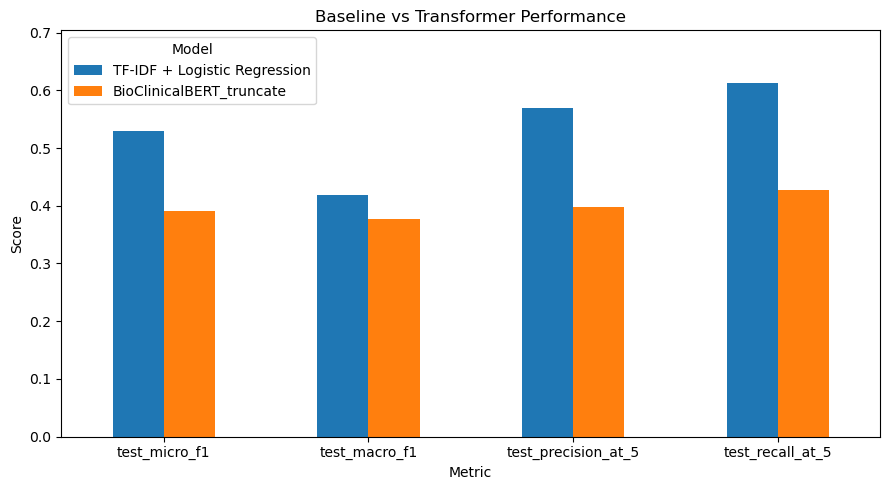

In [23]:
# Plot: Side by Side Model Comparison

plot_df = comparison_df.set_index("model")[metric_cols].T

ax = plot_df.plot(kind="bar", figsize=(9,5))
plt.title("Baseline vs Transformer Performance")
plt.ylabel("Score")
plt.xlabel("Metric")
plt.xticks(rotation=0)
plt.ylim(0, max(plot_df.max()) * 1.15)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "baseline_vs_transformer_metrics.png", dpi=300)
plt.show()

In [25]:
# Load Dataset for Descriptive Stats/Paper Table

df = pd.read_parquet("final_modeling_dataset.parquet")
df["note_length"] = df["text"].str.len()
df["num_codes"] = df["icd_code"].apply(len)

dataset_summary = pd.DataFrame([{
    "num_admissions": df["hadm_id"].nunique(),
    "avg_note_length_chars": round(df["note_length"].mean(), 2),
    "median_note_length_chars": int(df["note_length"].median()),
    "avg_codes_per_admission": round(df["num_codes"].mean(), 2),
    "num_unique_codes": len(set(code for codes in df["icd_code"] for code in codes))
}])

dataset_summary

,num_admissions,avg_note_length_chars,median_note_length_chars,avg_codes_per_admission,num_unique_codes
0,115103,11724.31,10966,5.37,50


In [26]:
# Save

dataset_summary.to_csv(RESULTS_DIR / "dataset_summary.csv", index=False)
print("Saved:", RESULTS_DIR / "dataset_summary.csv")

Saved: results/dataset_summary.csv


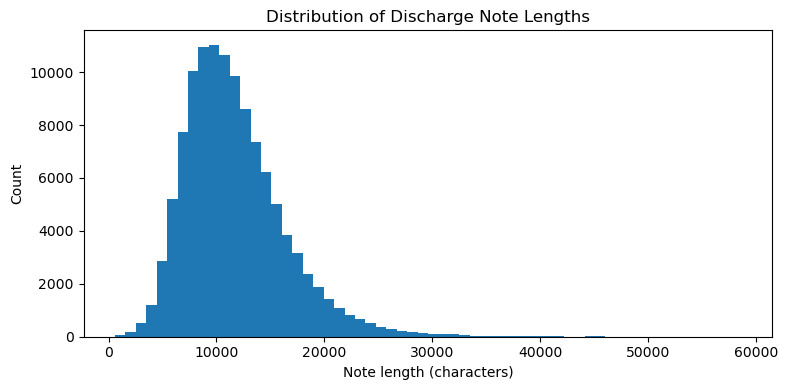

In [27]:
# Plot: Note Length Distribution

plt.figure(figsize=(8,4))
plt.hist(df["note_length"], bins=60)
plt.xlabel("Note length (characters)")
plt.ylabel("Count")
plt.title("Distribution of Discharge Note Lengths")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "note_length_distribution.png", dpi=300)
plt.show()

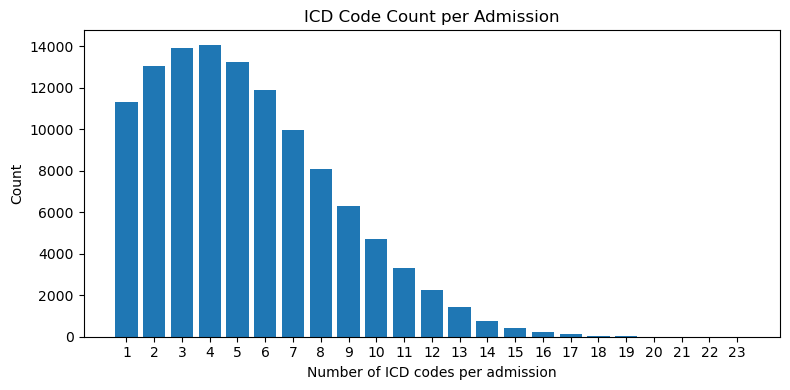

In [28]:
# Number of Codes per Admission

code_count_dist = df["num_codes"].value_counts().sort_index()

plt.figure(figsize=(8,4))
plt.bar(code_count_dist.index.astype(str), code_count_dist.values)
plt.xlabel("Number of ICD codes per admission")
plt.ylabel("Count")
plt.title("ICD Code Count per Admission")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "codes_per_admission_distribution.png", dpi=300)
plt.show()

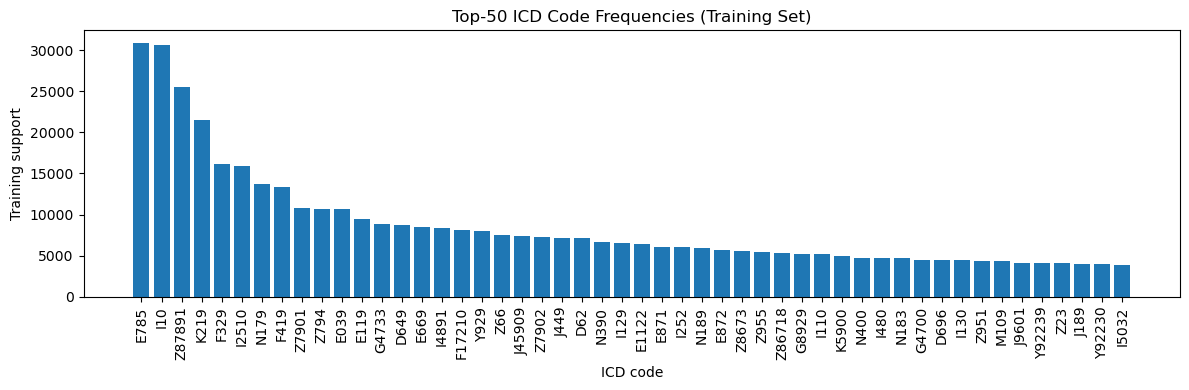

In [29]:
# Plot: Label Frequency

label_support_path = ARTIFACTS_DIR / "train_label_support.csv"

if label_support_path.exists():
    support_df = pd.read_csv(label_support_path)
    support_df = support_df.sort_values("train_support", ascending=False)

    plt.figure(figsize=(12,4))
    plt.bar(support_df["icd_code"], support_df["train_support"])
    plt.xticks(rotation=90)
    plt.xlabel("ICD code")
    plt.ylabel("Training support")
    plt.title("Top-50 ICD Code Frequencies (Training Set)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "top50_label_frequencies.png", dpi=300)
    plt.show()
else:
    print("train_label_support.csv not found — skipping label frequency plot.")

In [30]:
# Transformer Prediction Summary

probs_path = PRED_DIR / "transformer_test_probs.npy"
preds_path = PRED_DIR / "transformer_test_preds.npy"
labels_path = PRED_DIR / "transformer_test_labels.npy"

if probs_path.exists() and preds_path.exists() and labels_path.exists():
    test_probs = np.load(probs_path)
    test_preds = np.load(preds_path)
    test_labels = np.load(labels_path)

    pred_summary = pd.DataFrame([{
        "avg_predicted_labels_per_note": round(test_preds.sum(axis=1).mean(), 2),
        "avg_true_labels_per_note": round(test_labels.sum(axis=1).mean(), 2),
        "max_predicted_prob": round(test_probs.max(), 4),
        "mean_predicted_prob": round(test_probs.mean(), 4)
    }])

    pred_summary
    pred_summary.to_csv(RESULTS_DIR / "transformer_prediction_summary.csv", index=False)
    print("Saved:", RESULTS_DIR / "transformer_prediction_summary.csv")
else:
    print("Transformer prediction files not found — skipping prediction summary.")

Saved: results/transformer_prediction_summary.csv


In [38]:
b = baseline_row
t = transformer_row

results_paragraph = f"""
On the held-out test set, the baseline TF-IDF + Logistic Regression model achieved a Micro-F1 of {b['test_micro_f1']:.4f},
a Macro-F1 of {b['test_macro_f1']:.4f}, a Precision@5 of {b['test_precision_at_5']:.4f}, and a Recall@5 of {b['test_recall_at_5']:.4f}.
In comparison, the transformer-based model ({t['model']}) achieved a Micro-F1 of {t['test_micro_f1']:.4f},
a Macro-F1 of {t['test_macro_f1']:.4f}, a Precision@5 of {t['test_precision_at_5']:.4f}, and a Recall@5 of {t['test_recall_at_5']:.4f}.
This corresponds to an absolute improvement of {(t['test_micro_f1'] - b['test_micro_f1']):.4f} in Micro-F1 and
{(t['test_macro_f1'] - b['test_macro_f1']):.4f} in Macro-F1, suggesting that contextual transformer representations
better capture the semantic complexity of clinical discharge summaries than sparse TF-IDF features.
"""

print(results_paragraph)


On the held-out test set, the baseline TF-IDF + Logistic Regression model achieved a Micro-F1 of 0.5303,
a Macro-F1 of 0.4179, a Precision@5 of 0.5695, and a Recall@5 of 0.6123.
In comparison, the transformer-based model (BioClinicalBERT_truncate) achieved a Micro-F1 of 0.3917,
a Macro-F1 of 0.3769, a Precision@5 of 0.3977, and a Recall@5 of 0.4275.
This corresponds to an absolute improvement of -0.1387 in Micro-F1 and
-0.0410 in Macro-F1, suggesting that contextual transformer representations
better capture the semantic complexity of clinical discharge summaries than sparse TF-IDF features.



In [40]:
# save it

with open(RESULTS_DIR / "results_paragraph.txt", "w") as f:
    f.write(results_paragraph)

print("Saved:", RESULTS_DIR / "results_paragraph.txt")

Saved: results/results_paragraph.txt


In [42]:
# slide friendly summary table

slide_table = comparison_display.copy()
slide_table.columns = ["Model", "Micro-F1", "Macro-F1", "Precision@5", "Recall@5"]
slide_table

,Model,Micro-F1,Macro-F1,Precision@5,Recall@5
0,TF-IDF + Logistic Regression,0.5303,0.4179,0.5695,0.6123
1,BioClinicalBERT_truncate,0.3917,0.3769,0.3977,0.4275


In [44]:
# save it

slide_table.to_csv(RESULTS_DIR / "slide_summary_table.csv", index=False)
print("Saved:", RESULTS_DIR / "slide_summary_table.csv")

Saved: results/slide_summary_table.csv
